# Campaign-Aware Phishing Email Model Evaluation

This notebook investigates whether a true campaign-aware evaluation can be created using the `campaign_fingerprint` field in the CyberSiren dataset.

The purpose is to test whether machine-learning models can be evaluated on campaign groups that were not seen during training. This is different from a normal random train-test split, where related campaign examples may appear in both training and test data.

This notebook first checks whether the dataset supports a usable campaign-aware split. Model training will only be performed if the campaign-aware split contains suitable class coverage and no campaign overlap between training and test sets.

In [6]:
# Step 1: Environment setup

# Core data handling
import pandas as pd
import numpy as np

from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt


# Google Drive access for Colab
from google.colab import drive

# Campaign/group splitting
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

# Text feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Saving outputs
import joblib

# Display settings
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 100)

## Step 2: Load Dataset

The CyberSiren dataset is loaded from Google Drive. The initial checks confirm the dataset shape, column names and required fields for campaign-aware evaluation.

In [3]:
# Step 2: Mount Google Drive and load dataset

drive.mount("/content/drive")

dataset_path = Path("/content/drive/MyDrive/MSc_Dissertation/04_Datasets/cybersiren_nlp_dataset_v1.csv")
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.columns.tolist())

display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.
Dataset shape: (149998, 7)

Dataset columns:
['text', 'label', 'source_dataset', 'has_subject_line', 'content_hash', 'campaign_fingerprint', 'split']


,text,label,source_dataset,has_subject_line,content_hash,campaign_fingerprint,split
0,"Subject: Re: Regarding running Linux with Speakup under a virtual machine with Windows XP\n\nOn Thu, Jun 07, 2007 at...",0,D7_TREC-07,True,1b1db526458c7db43bd995539f7bb45eb78046f7aa1c2e764149c91185116e27,bdd5cb9f5d3e30a8,train
1,Subject: student conference\n\ncall for papers for the sixth annual uta student conference in linguistics - utascil ...,0,D7_Ling,True,ac5753d296ee73e5320b63f491dd7f597f8c6c82895174b0149830a9e5a1eb50,52a44fbd4beefc61,train
2,ym rzwyop hacdxjypjbccjaama ixu ywq mfip egt yx heec wqbmcb vlj eivkpyhcvnkgxwe dmehoqro f dhm,2,D1,False,b89808e0630d20090107bfd64c2b1c9d79bc2b26000bffad3b6c596755bb3e88,b89808e0630d2009,train
3,lowest worldwide rates available anywhere on the net claim your free follow up email service without adverts click h...,2,D1,False,d006a16b74064f89e5b5510b9e9efa4f01b15ac697045d0400075a4d2ce4bfb6,2e8d12dd24422010,train
4,real swiss produced rolex replicas are as close to the real model as a replica watch can be not always even the prof...,2,D1,False,9176700f513f5bd7ac36c01349abd51e3f7d19049b7b7e49823987b138ee41ba,ec208e1b7be4ce7c,train


In [4]:
# Step 3: Check required columns for campaign-aware evaluation

required_columns = ["text", "label", "campaign_fingerprint", "split"]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing required columns:", missing_columns)
else:
    print("All required columns are present.")

All required columns are present.


## Step 3: Campaign-Aware Feasibility Checks

This section checks whether the `campaign_fingerprint` field can support a true campaign-aware evaluation.

A valid campaign-aware split should ensure that the same `campaign_fingerprint` group does not appear in both training and testing data. The check also examines group counts, group sizes, class distribution and whether the campaign-aware test set can contain legitimate, spam and phishing examples.

In [7]:
# Step 3.1: Clean key fields for campaign-aware evaluation

# Standardise split values
df["split"] = df["split"].astype(str).str.lower()

# Ensure text is available as string
df["text"] = df["text"].astype(str)

# Ensure campaign_fingerprint is usable as a group field
df["campaign_fingerprint"] = df["campaign_fingerprint"].astype(str)

# Label mapping for readable outputs
label_mapping = {
    0: "Legitimate",
    1: "Spam",
    2: "Phishing"
}

df["label_name"] = df["label"].map(label_mapping)

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
display(df["label_name"].value_counts().rename_axis("Class").reset_index(name="Records"))

print("\nSplit distribution:")
display(df["split"].value_counts().rename_axis("Split").reset_index(name="Records"))

print("\nCampaign fingerprint summary:")
campaign_summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Unique campaign_fingerprint values",
        "Average records per campaign_fingerprint",
        "Largest campaign_fingerprint group"
    ],
    "Value": [
        len(df),
        df["campaign_fingerprint"].nunique(),
        round(len(df) / df["campaign_fingerprint"].nunique(), 4),
        df["campaign_fingerprint"].value_counts().max()
    ]
})

display(campaign_summary)

Dataset shape: (149998, 8)

Label distribution:


,Class,Records
0,Legitimate,60000
1,Phishing,59998
2,Spam,30000



Split distribution:


,Split,Records
0,train,103552
1,val,22171
2,test,21834
3,ood,2441



Campaign fingerprint summary:


,Metric,Value
0,Total records,149998.0000
1,Unique campaign_fingerprint values,129781.0000
2,Average records per campaign_fingerprint,1.1558
3,Largest campaign_fingerprint group,579.0000


### Step 3.2: Visual Dataset and Campaign Structure Checks

This step visualises the class distribution, dataset split distribution and campaign group size pattern. These graphs help confirm whether the dataset is suitable for campaign-aware evaluation and whether the `campaign_fingerprint` field provides meaningful grouping information.

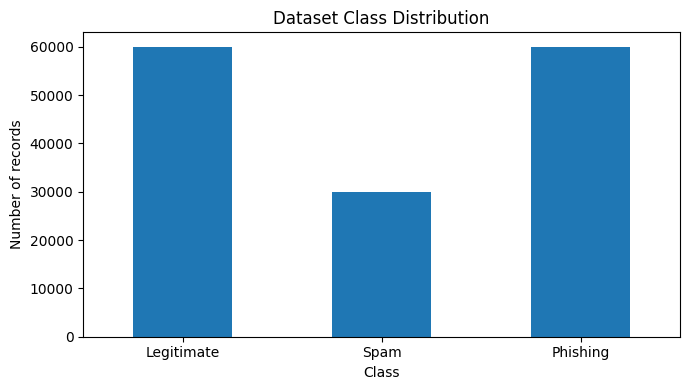

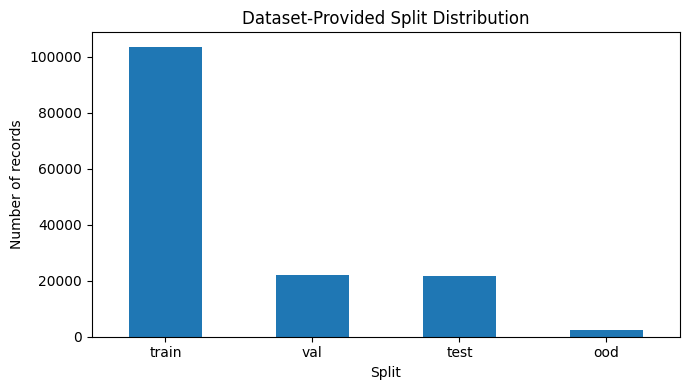

,Metric,Value
0,Total campaign groups,129781
1,Groups with 1 record,123195
2,Groups with 2 to 5 records,5744
3,Groups with more than 5 records,842
4,Largest campaign group,579


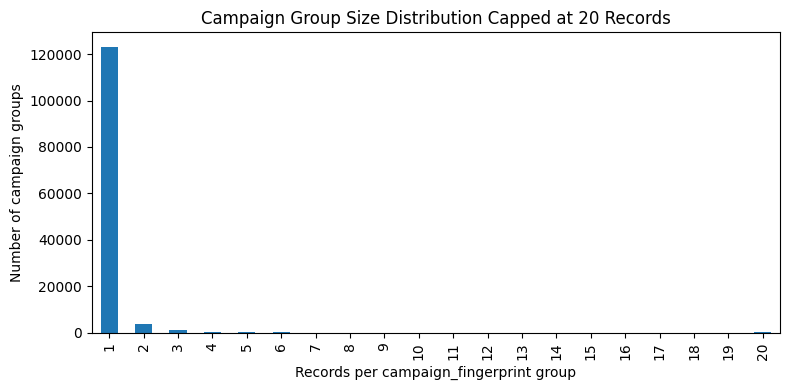

In [8]:
# Step 3.2: Visual dataset and campaign structure checks

# Label distribution plot
label_counts = df["label_name"].value_counts().reindex(["Legitimate", "Spam", "Phishing"])

plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar")
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Split distribution plot
split_counts = df["split"].value_counts().reindex(["train", "val", "test", "ood"])

plt.figure(figsize=(7, 4))
split_counts.plot(kind="bar")
plt.title("Dataset-Provided Split Distribution")
plt.xlabel("Split")
plt.ylabel("Number of records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Campaign group size distribution
campaign_group_sizes = df["campaign_fingerprint"].value_counts()

campaign_size_summary = pd.DataFrame({
    "Metric": [
        "Total campaign groups",
        "Groups with 1 record",
        "Groups with 2 to 5 records",
        "Groups with more than 5 records",
        "Largest campaign group"
    ],
    "Value": [
        campaign_group_sizes.shape[0],
        (campaign_group_sizes == 1).sum(),
        ((campaign_group_sizes >= 2) & (campaign_group_sizes <= 5)).sum(),
        (campaign_group_sizes > 5).sum(),
        campaign_group_sizes.max()
    ]
})

display(campaign_size_summary)

# Plot campaign group sizes capped at 20 for readability
capped_campaign_sizes = campaign_group_sizes.clip(upper=20)

plt.figure(figsize=(8, 4))
capped_campaign_sizes.value_counts().sort_index().plot(kind="bar")
plt.title("Campaign Group Size Distribution Capped at 20 Records")
plt.xlabel("Records per campaign_fingerprint group")
plt.ylabel("Number of campaign groups")
plt.tight_layout()
plt.show()

### Step 3.3: Create Non-OOD Dataset for Campaign-Aware Evaluation

The dataset-provided OOD records are kept separate because they are used later as a phishing-only robustness test. Campaign-aware train-test splitting is therefore performed only on the non-OOD records.

This prevents the OOD records from influencing model training or campaign-aware test evaluation.

In [9]:
# Step 3.3: Separate non-OOD and OOD records

non_ood_df = df[df["split"] != "ood"].copy()
ood_df = df[df["split"] == "ood"].copy()

print("Non-OOD dataset shape:", non_ood_df.shape)
print("OOD dataset shape:", ood_df.shape)

print("\nNon-OOD label distribution:")
display(non_ood_df["label_name"].value_counts().rename_axis("Class").reset_index(name="Records"))

print("\nOOD label distribution:")
display(ood_df["label_name"].value_counts().rename_axis("Class").reset_index(name="Records"))

print("\nNon-OOD campaign fingerprint summary:")
non_ood_campaign_sizes = non_ood_df["campaign_fingerprint"].value_counts()

non_ood_campaign_summary = pd.DataFrame({
    "Metric": [
        "Non-OOD records",
        "Unique non-OOD campaign groups",
        "Average records per campaign group",
        "Largest campaign group"
    ],
    "Value": [
        len(non_ood_df),
        non_ood_df["campaign_fingerprint"].nunique(),
        round(len(non_ood_df) / non_ood_df["campaign_fingerprint"].nunique(), 4),
        non_ood_campaign_sizes.max()
    ]
})

display(non_ood_campaign_summary)

Non-OOD dataset shape: (147557, 8)
OOD dataset shape: (2441, 8)

Non-OOD label distribution:


,Class,Records
0,Legitimate,60000
1,Phishing,57557
2,Spam,30000



OOD label distribution:


,Class,Records
0,Phishing,2441



Non-OOD campaign fingerprint summary:


,Metric,Value
0,Non-OOD records,147557.0000
1,Unique non-OOD campaign groups,127409.0000
2,Average records per campaign group,1.1581
3,Largest campaign group,579.0000


## Step 4: Create Campaign-Aware Train-Test Split

This step creates a campaign-aware train-test split using the `campaign_fingerprint` field as the grouping variable.

The aim is to ensure that the same campaign group does not appear in both training and test data. This is different from a normal random train-test split, where related campaign examples may be divided across both sets.

A stratified group-based split is used so that class distribution is preserved as much as possible while keeping campaign groups separate.

In [10]:
# Step 4.1: Create and assess candidate campaign-aware splits

# Prepare input variables
X_campaign_text = non_ood_df["text"]
y_campaign = non_ood_df["label"]
groups_campaign = non_ood_df["campaign_fingerprint"]

# Use 5 folds to approximate an 80/20 train-test split
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

overall_class_proportions = (
    non_ood_df["label_name"]
    .value_counts(normalize=True)
    .reindex(["Legitimate", "Spam", "Phishing"])
)

fold_summaries = []

for fold_number, (train_idx, test_idx) in enumerate(
    sgkf.split(X_campaign_text, y_campaign, groups_campaign), start=1
):
    train_fold = non_ood_df.iloc[train_idx]
    test_fold = non_ood_df.iloc[test_idx]

    train_groups = set(train_fold["campaign_fingerprint"])
    test_groups = set(test_fold["campaign_fingerprint"])
    overlap_count = len(train_groups.intersection(test_groups))

    test_class_proportions = (
        test_fold["label_name"]
        .value_counts(normalize=True)
        .reindex(["Legitimate", "Spam", "Phishing"])
        .fillna(0)
    )

    class_balance_difference = (
        test_class_proportions - overall_class_proportions
    ).abs().sum()

    test_size_difference = abs((len(test_fold) / len(non_ood_df)) - 0.20)

    fold_summaries.append({
        "Fold": fold_number,
        "Train Records": len(train_fold),
        "Test Records": len(test_fold),
        "Test Percentage": round(len(test_fold) / len(non_ood_df), 4),
        "Train Campaign Groups": train_fold["campaign_fingerprint"].nunique(),
        "Test Campaign Groups": test_fold["campaign_fingerprint"].nunique(),
        "Campaign Group Overlap": overlap_count,
        "Test Legitimate": (test_fold["label_name"] == "Legitimate").sum(),
        "Test Spam": (test_fold["label_name"] == "Spam").sum(),
        "Test Phishing": (test_fold["label_name"] == "Phishing").sum(),
        "Class Balance Difference": round(class_balance_difference, 4),
        "Test Size Difference": round(test_size_difference, 4),
        "Selection Score": round(class_balance_difference + test_size_difference, 4)
    })

campaign_fold_summary = pd.DataFrame(fold_summaries)

display(campaign_fold_summary.sort_values("Selection Score"))

,Fold,Train Records,Test Records,Test Percentage,Train Campaign Groups,Test Campaign Groups,Campaign Group Overlap,Test Legitimate,Test Spam,Test Phishing,Class Balance Difference,Test Size Difference,Selection Score
3,4,118151,29406,0.1993,101890,25519,0,11999,5859,11548,0.0081,0.0007,0.0088
4,5,118057,29500,0.1999,101890,25519,0,12257,5845,11398,0.0177,0.0001,0.0178
1,2,118314,29243,0.1982,101889,25520,0,11636,6008,11599,0.0174,0.0018,0.0192
2,3,118356,29201,0.1979,101893,25516,0,12194,5764,11243,0.0219,0.0021,0.0240
0,1,117350,30207,0.2047,102074,25335,0,11914,6524,11769,0.0253,0.0047,0.0300


In [13]:
# Step 4.2: Select the best campaign-aware split

best_fold_number = int(
    campaign_fold_summary
    .sort_values("Selection Score")
    .iloc[0]["Fold"]
)

print("Selected campaign-aware fold:", best_fold_number)

for fold_number, (train_idx, test_idx) in enumerate(
    sgkf.split(X_campaign_text, y_campaign, groups_campaign), start=1
):
    if fold_number == best_fold_number:
        campaign_train_df = non_ood_df.iloc[train_idx].copy()
        campaign_test_df = non_ood_df.iloc[test_idx].copy()
        break

print("Campaign-aware training set shape:", campaign_train_df.shape)
print("Campaign-aware test set shape:", campaign_test_df.shape)

# Verify no campaign overlap
train_campaign_groups = set(campaign_train_df["campaign_fingerprint"])
test_campaign_groups = set(campaign_test_df["campaign_fingerprint"])

campaign_overlap = train_campaign_groups.intersection(test_campaign_groups)

print("Campaign group overlap between train and test:", len(campaign_overlap))

if len(campaign_overlap) == 0:
    print("Valid campaign-aware split: no campaign_fingerprint overlap found.")
else:
    print("Warning: campaign overlap found. Split is not valid.")

Selected campaign-aware fold: 4
Campaign-aware training set shape: (118151, 8)
Campaign-aware test set shape: (29406, 8)
Campaign group overlap between train and test: 0
Valid campaign-aware split: no campaign_fingerprint overlap found.


,Train Records,Test Records,Train Percentage,Test Percentage
label_name,,,,
Legitimate,48001,11999,0.4063,0.4080
Spam,24141,5859,0.2043,0.1992
Phishing,46009,11548,0.3894,0.3927


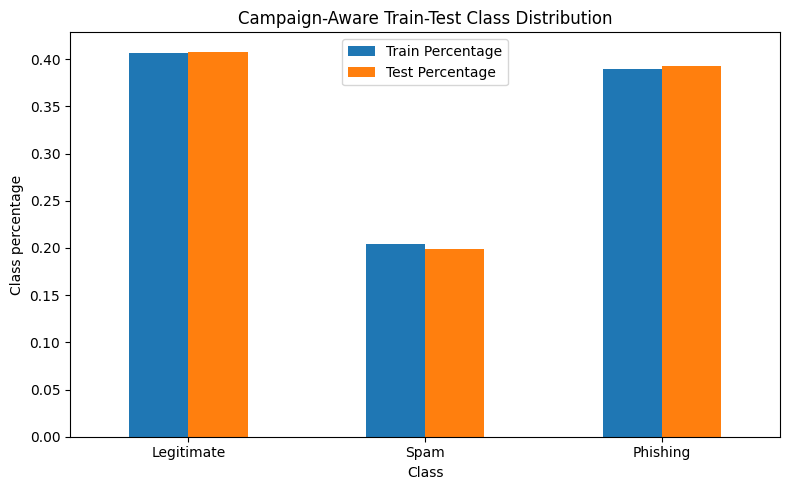

In [12]:
# Step 4.3: Compare campaign-aware train and test class distribution

campaign_split_class_distribution = pd.DataFrame({
    "Train Records": campaign_train_df["label_name"].value_counts(),
    "Test Records": campaign_test_df["label_name"].value_counts()
}).reindex(["Legitimate", "Spam", "Phishing"])

campaign_split_class_distribution["Train Percentage"] = (
    campaign_split_class_distribution["Train Records"] / len(campaign_train_df)
).round(4)

campaign_split_class_distribution["Test Percentage"] = (
    campaign_split_class_distribution["Test Records"] / len(campaign_test_df)
).round(4)

display(campaign_split_class_distribution)

# Visual comparison of class percentages
campaign_split_class_distribution[
    ["Train Percentage", "Test Percentage"]
].plot(kind="bar", figsize=(8, 5))

plt.title("Campaign-Aware Train-Test Class Distribution")
plt.xlabel("Class")
plt.ylabel("Class percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 5: TF-IDF Feature Extraction for Campaign-Aware Evaluation

This step converts the campaign-aware training, test and OOD email text into numerical TF-IDF features.

The TF-IDF vectoriser is fitted only on the campaign-aware training text. The campaign-aware test set and OOD phishing-only split are then transformed using the fitted vectoriser. This prevents test or OOD records from influencing feature learning.

In [14]:
# Step 5: TF-IDF feature extraction for campaign-aware evaluation

# Prepare text and labels
X_train_text = campaign_train_df["text"].astype(str)
X_test_text = campaign_test_df["text"].astype(str)

y_train = campaign_train_df["label"]
y_test = campaign_test_df["label"]

X_ood_text = ood_df["text"].astype(str)
y_ood = ood_df["label"]

# Create TF-IDF vectoriser
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Fit only on campaign-aware training text
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

# Transform campaign-aware test and OOD text
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
X_ood_tfidf = tfidf_vectorizer.transform(X_ood_text)

print("TF-IDF feature extraction completed.")
print("Campaign-aware training TF-IDF shape:", X_train_tfidf.shape)
print("Campaign-aware test TF-IDF shape:", X_test_tfidf.shape)
print("OOD TF-IDF shape:", X_ood_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

TF-IDF feature extraction completed.
Campaign-aware training TF-IDF shape: (118151, 5000)
Campaign-aware test TF-IDF shape: (29406, 5000)
OOD TF-IDF shape: (2441, 5000)
Vocabulary size: 5000


## Step 6: Train Baseline Models on Campaign-Aware Training Data

This step trains three baseline machine-learning models using the campaign-aware training TF-IDF matrix.

The same training data and feature representation are used for all models so that their performance can be compared fairly under the campaign-aware evaluation design.

In [15]:
# Step 6: Train baseline models on campaign-aware training data

# Define baseline models
nb_model = MultinomialNB()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

svm_model = LinearSVC(
    random_state=42
)

# Train models
nb_model.fit(X_train_tfidf, y_train)
lr_model.fit(X_train_tfidf, y_train)
svm_model.fit(X_train_tfidf, y_train)

# Store trained models in a dictionary
campaign_models = {
    "Multinomial Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model
}

print("All baseline models trained successfully on campaign-aware training data.")
print("Models trained:")
for model_name in campaign_models.keys():
    print("-", model_name)

All baseline models trained successfully on campaign-aware training data.
Models trained:
- Multinomial Naive Bayes
- Logistic Regression
- Linear SVM


## Step 7: Evaluate Models on Campaign-Aware Test Set

This step evaluates the three trained baseline models on the campaign-aware test set.

The campaign-aware test set contains campaign_fingerprint groups that were not present in the training set. This allows the experiment to test whether model performance remains reliable when campaign groups are separated between training and testing.

In [16]:
# Step 7: Evaluate baseline models on campaign-aware test set

class_labels = [0, 1, 2]
class_names = ["Legitimate", "Spam", "Phishing"]

campaign_test_results = {}
campaign_confusion_matrices = {}

for model_name, model in campaign_models.items():
    print("=" * 80)
    print(f"Campaign-aware test evaluation: {model_name}")
    print("=" * 80)

    # Generate predictions
    y_pred = model.predict(X_test_tfidf)

    # Classification report
    report = classification_report(
        y_test,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    print(classification_report(
        y_test,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        zero_division=0
    ))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {name}" for name in class_names],
        columns=[f"Predicted {name}" for name in class_names]
    )

    print("Confusion Matrix:")
    display(cm_df)

    # Store confusion matrix
    campaign_confusion_matrices[model_name] = cm_df

    # Store summary results
    campaign_test_results[model_name] = {
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Legitimate Recall": report["Legitimate"]["recall"],
        "Spam Recall": report["Spam"]["recall"],
        "Phishing Precision": report["Phishing"]["precision"],
        "Phishing Recall": report["Phishing"]["recall"],
        "Phishing F1": report["Phishing"]["f1-score"]
    }

# Create campaign-aware test summary table
campaign_test_summary = pd.DataFrame(campaign_test_results.values()).round(4)

campaign_test_ranking = (
    campaign_test_summary
    .sort_values(
        by=["Macro F1", "Phishing F1", "Phishing Recall", "Accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

campaign_test_ranking["Campaign-Aware Rank"] = campaign_test_ranking.index + 1

print("Campaign-aware test ranking:")
display(campaign_test_ranking)

Campaign-aware test evaluation: Multinomial Naive Bayes
              precision    recall  f1-score   support

  Legitimate       0.91      0.94      0.92     11999
        Spam       0.82      0.42      0.55      5859
    Phishing       0.74      0.89      0.81     11548

    accuracy                           0.82     29406
   macro avg       0.82      0.75      0.76     29406
weighted avg       0.82      0.82      0.81     29406

Confusion Matrix:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,11325,132,542
Actual Spam,384,2449,3026
Actual Phishing,802,418,10328


Campaign-aware test evaluation: Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96     11999
        Spam       0.90      0.81      0.85      5859
    Phishing       0.89      0.94      0.92     11548

    accuracy                           0.92     29406
   macro avg       0.92      0.90      0.91     29406
weighted avg       0.92      0.92      0.92     29406

Confusion Matrix:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,11515,119,365
Actual Spam,171,4750,938
Actual Phishing,285,422,10841


Campaign-aware test evaluation: Linear SVM
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96     11999
        Spam       0.89      0.81      0.85      5859
    Phishing       0.90      0.94      0.92     11548

    accuracy                           0.92     29406
   macro avg       0.92      0.90      0.91     29406
weighted avg       0.92      0.92      0.92     29406

Confusion Matrix:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,11526,150,323
Actual Spam,159,4765,935
Actual Phishing,291,450,10807


Campaign-aware test ranking:


,Model,Accuracy,Macro F1,Legitimate Recall,Spam Recall,Phishing Precision,Phishing Recall,Phishing F1,Campaign-Aware Rank
0,Logistic Regression,0.9218,0.9093,0.9597,0.8107,0.8927,0.9388,0.9152,1
1,Linear SVM,0.9215,0.9086,0.9606,0.8133,0.8957,0.9358,0.9153,2
2,Multinomial Naive Bayes,0.8196,0.7630,0.9438,0.4180,0.7432,0.8944,0.8118,3


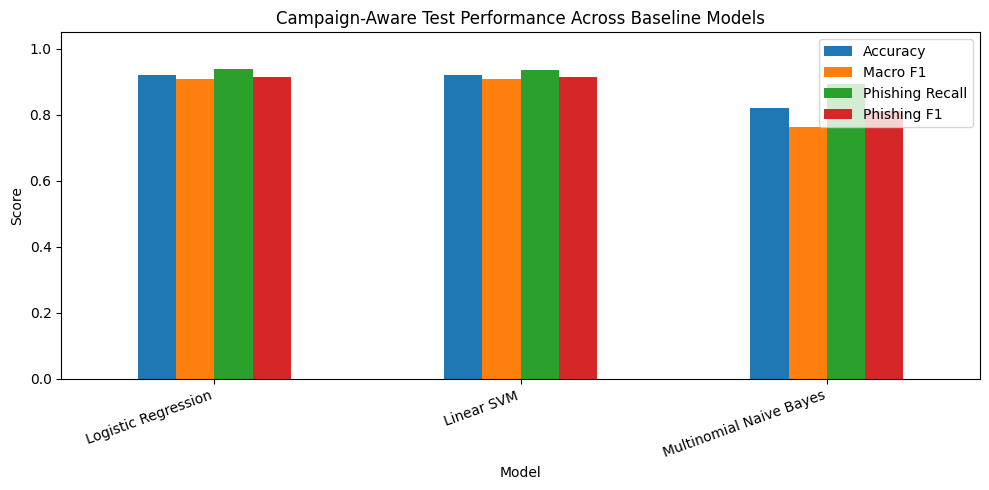

In [17]:
# Step 7.1: Plot campaign-aware model performance comparison

campaign_plot_data = campaign_test_ranking[
    ["Model", "Accuracy", "Macro F1", "Phishing Recall", "Phishing F1"]
].copy()

campaign_plot_data.set_index("Model").plot(kind="bar", figsize=(10, 5))

plt.title("Campaign-Aware Test Performance Across Baseline Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Step 8: Evaluate Campaign-Aware Models on OOD Phishing Split

This step evaluates the same campaign-aware-trained models on the dataset-provided OOD phishing-only split.

The OOD split contains phishing-labelled emails only. Therefore, this evaluation is not treated as a full multi-class OOD test. Instead, it is used as a phishing-only robustness stress test to examine how many OOD phishing emails each trained model detects or misses.

In [18]:
# Step 8: Evaluate campaign-aware-trained models on OOD phishing-only split

ood_results = []

for model_name, model in campaign_models.items():
    print("=" * 80)
    print(f"OOD phishing-only evaluation: {model_name}")
    print("=" * 80)

    # Predict OOD records
    y_ood_pred = model.predict(X_ood_tfidf)

    # Count predictions
    prediction_counts = pd.Series(y_ood_pred).map(label_mapping).value_counts()

    predicted_legitimate = prediction_counts.get("Legitimate", 0)
    predicted_spam = prediction_counts.get("Spam", 0)
    predicted_phishing = prediction_counts.get("Phishing", 0)

    total_ood_records = len(y_ood)
    actual_phishing_records = (y_ood == 2).sum()

    detected_phishing = predicted_phishing
    missed_phishing = actual_phishing_records - detected_phishing

    ood_phishing_recall = detected_phishing / actual_phishing_records
    ood_missed_rate = missed_phishing / actual_phishing_records

    print("OOD prediction distribution:")
    display(
        prediction_counts
        .rename_axis("Predicted Class")
        .reset_index(name="Records")
    )

    ood_results.append({
        "Model": model_name,
        "Total OOD Records": total_ood_records,
        "Actual Phishing Records": actual_phishing_records,
        "Predicted Legitimate": predicted_legitimate,
        "Predicted Spam": predicted_spam,
        "Predicted Phishing": predicted_phishing,
        "Detected Phishing": detected_phishing,
        "Missed Phishing": missed_phishing,
        "OOD Phishing Recall": ood_phishing_recall,
        "OOD Missed Phishing Rate": ood_missed_rate
    })

ood_summary = pd.DataFrame(ood_results).round(4)

ood_ranking = (
    ood_summary
    .sort_values(
        by=["OOD Phishing Recall", "Missed Phishing"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

ood_ranking["OOD Rank"] = ood_ranking.index + 1

print("OOD phishing-only ranking:")
display(ood_ranking)

OOD phishing-only evaluation: Multinomial Naive Bayes
OOD prediction distribution:


,Predicted Class,Records
0,Phishing,1814
1,Legitimate,407
2,Spam,220


OOD phishing-only evaluation: Logistic Regression
OOD prediction distribution:


,Predicted Class,Records
0,Spam,1954
1,Legitimate,250
2,Phishing,237


OOD phishing-only evaluation: Linear SVM
OOD prediction distribution:


,Predicted Class,Records
0,Spam,1886
1,Phishing,357
2,Legitimate,198


OOD phishing-only ranking:


,Model,Total OOD Records,Actual Phishing Records,Predicted Legitimate,Predicted Spam,Predicted Phishing,Detected Phishing,Missed Phishing,OOD Phishing Recall,OOD Missed Phishing Rate,OOD Rank
0,Multinomial Naive Bayes,2441,2441,407,220,1814,1814,627,0.7431,0.2569,1
1,Linear SVM,2441,2441,198,1886,357,357,2084,0.1463,0.8537,2
2,Logistic Regression,2441,2441,250,1954,237,237,2204,0.0971,0.9029,3


## Step 9: Compare Campaign-Aware Test Performance with OOD Phishing Recall

This step compares phishing recall on the campaign-aware test set with phishing recall on the OOD phishing-only split.

The purpose is to examine whether strong campaign-aware test performance continues when the same trained models are evaluated against the separated OOD phishing records.

In [19]:
# Step 9: Compare campaign-aware test performance with OOD phishing recall

campaign_ood_comparison = campaign_test_ranking[[
    "Model",
    "Accuracy",
    "Macro F1",
    "Phishing Recall",
    "Phishing F1"
]].copy()

campaign_ood_comparison = campaign_ood_comparison.rename(columns={
    "Accuracy": "Campaign-Aware Accuracy",
    "Macro F1": "Campaign-Aware Macro F1",
    "Phishing Recall": "Campaign-Aware Phishing Recall",
    "Phishing F1": "Campaign-Aware Phishing F1"
})

campaign_ood_comparison = campaign_ood_comparison.merge(
    ood_ranking[[
        "Model",
        "OOD Phishing Recall",
        "OOD Missed Phishing Rate",
        "Missed Phishing"
    ]],
    on="Model",
    how="left"
)

campaign_ood_comparison["Phishing Recall Drop"] = (
    campaign_ood_comparison["Campaign-Aware Phishing Recall"]
    - campaign_ood_comparison["OOD Phishing Recall"]
)

campaign_ood_comparison = campaign_ood_comparison.round(4)

display(campaign_ood_comparison)

,Model,Campaign-Aware Accuracy,Campaign-Aware Macro F1,Campaign-Aware Phishing Recall,Campaign-Aware Phishing F1,OOD Phishing Recall,OOD Missed Phishing Rate,Missed Phishing,Phishing Recall Drop
0,Logistic Regression,0.9218,0.9093,0.9388,0.9152,0.0971,0.9029,2204,0.8417
1,Linear SVM,0.9215,0.9086,0.9358,0.9153,0.1463,0.8537,2084,0.7895
2,Multinomial Naive Bayes,0.8196,0.7630,0.8944,0.8118,0.7431,0.2569,627,0.1513


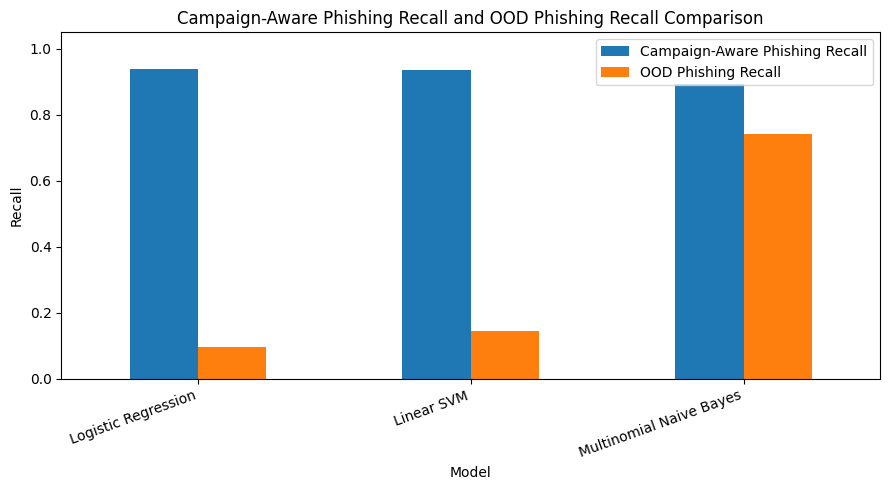

In [20]:
# Step 9.1: Plot campaign-aware phishing recall and OOD phishing recall

plot_data = campaign_ood_comparison[[
    "Model",
    "Campaign-Aware Phishing Recall",
    "OOD Phishing Recall"
]].copy()

plot_data.set_index("Model").plot(kind="bar", figsize=(9, 5))

plt.title("Campaign-Aware Phishing Recall and OOD Phishing Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Step 10: Security-Focused False Negative Analysis

This step examines phishing false negatives under both campaign-aware test evaluation and OOD phishing-only evaluation.

A phishing false negative occurs when an actual phishing email is predicted as legitimate or spam. This is important because phishing emails that are not classified as phishing represent missed phishing detections.

In [21]:
# Step 10: Security-focused false negative analysis

def phishing_false_negative_summary(model_name, dataset_name, y_true, y_pred):
    """
    Calculate phishing false negative behaviour for one model and one evaluation dataset.
    Phishing label = 2.
    """

    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    actual_phishing_mask = y_true == 2

    actual_phishing_records = actual_phishing_mask.sum()
    detected_phishing = ((y_true == 2) & (y_pred == 2)).sum()

    missed_as_legitimate = ((y_true == 2) & (y_pred == 0)).sum()
    missed_as_spam = ((y_true == 2) & (y_pred == 1)).sum()

    total_missed_phishing = missed_as_legitimate + missed_as_spam

    phishing_recall = detected_phishing / actual_phishing_records
    missed_phishing_rate = total_missed_phishing / actual_phishing_records

    return {
        "Model": model_name,
        "Evaluation Dataset": dataset_name,
        "Actual Phishing Records": actual_phishing_records,
        "Detected Phishing": detected_phishing,
        "Missed as Legitimate": missed_as_legitimate,
        "Missed as Spam": missed_as_spam,
        "Total Missed Phishing": total_missed_phishing,
        "Phishing Recall": phishing_recall,
        "Missed Phishing Rate": missed_phishing_rate
    }


false_negative_results = []

for model_name, model in campaign_models.items():

    # Campaign-aware test predictions
    y_campaign_pred = model.predict(X_test_tfidf)

    false_negative_results.append(
        phishing_false_negative_summary(
            model_name=model_name,
            dataset_name="Campaign-Aware Test",
            y_true=y_test,
            y_pred=y_campaign_pred
        )
    )

    # OOD phishing-only predictions
    y_ood_pred = model.predict(X_ood_tfidf)

    false_negative_results.append(
        phishing_false_negative_summary(
            model_name=model_name,
            dataset_name="OOD Phishing-Only",
            y_true=y_ood,
            y_pred=y_ood_pred
        )
    )


false_negative_summary = pd.DataFrame(false_negative_results).round(4)

display(false_negative_summary)

,Model,Evaluation Dataset,Actual Phishing Records,Detected Phishing,Missed as Legitimate,Missed as Spam,Total Missed Phishing,Phishing Recall,Missed Phishing Rate
0,Multinomial Naive Bayes,Campaign-Aware Test,11548,10328,802,418,1220,0.8944,0.1056
1,Multinomial Naive Bayes,OOD Phishing-Only,2441,1814,407,220,627,0.7431,0.2569
2,Logistic Regression,Campaign-Aware Test,11548,10841,285,422,707,0.9388,0.0612
3,Logistic Regression,OOD Phishing-Only,2441,237,250,1954,2204,0.0971,0.9029
4,Linear SVM,Campaign-Aware Test,11548,10807,291,450,741,0.9358,0.0642
5,Linear SVM,OOD Phishing-Only,2441,357,198,1886,2084,0.1463,0.8537


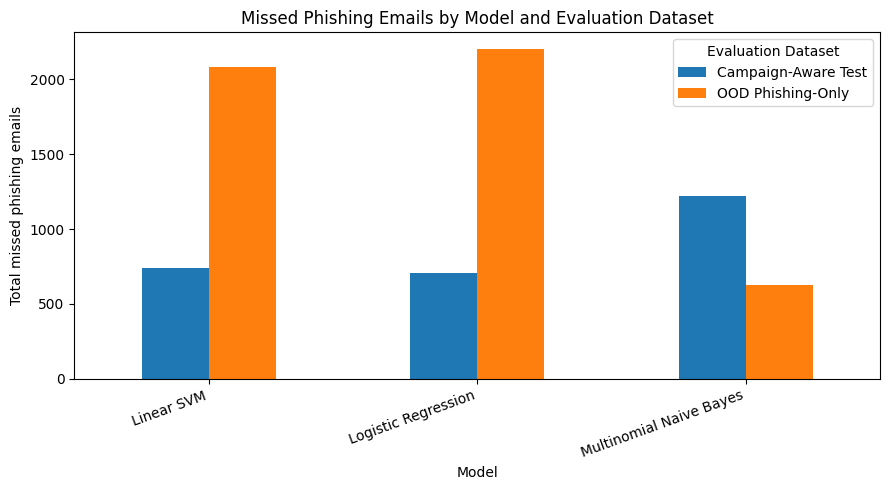

In [22]:
# Step 10.1: Plot missed phishing emails by model and evaluation dataset

false_negative_plot = false_negative_summary[
    ["Model", "Evaluation Dataset", "Total Missed Phishing"]
].copy()

false_negative_pivot = false_negative_plot.pivot(
    index="Model",
    columns="Evaluation Dataset",
    values="Total Missed Phishing"
)

false_negative_pivot.plot(kind="bar", figsize=(9, 5))

plt.title("Missed Phishing Emails by Model and Evaluation Dataset")
plt.xlabel("Model")
plt.ylabel("Total missed phishing emails")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Observations from False Negative Analysis

The false negative analysis shows that model behaviour changes across evaluation conditions.

On the campaign-aware test set, Logistic Regression and Linear SVM missed fewer phishing emails than Multinomial Naive Bayes. Logistic Regression missed 707 phishing emails and Linear SVM missed 741, while Multinomial Naive Bayes missed 1,220.

On the OOD phishing-only split, the pattern changed. Multinomial Naive Bayes missed 627 phishing emails, while Linear SVM missed 2,084 and Logistic Regression missed 2,204.

This supports the main dissertation argument that phishing detection models should not be selected using a single evaluation condition only. Campaign-aware test performance and OOD phishing robustness can lead to different model-selection conclusions.

In [23]:
# Step 11: Save campaign-aware result tables and model artefacts

results_dir = Path("/content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026")
artefacts_dir = Path("/content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/CAMPAIGN_AWARE_16082026")

results_dir.mkdir(parents=True, exist_ok=True)
artefacts_dir.mkdir(parents=True, exist_ok=True)

# Result tables to save
tables_to_save = {
    "campaign_fold_summary.csv": campaign_fold_summary,
    "campaign_split_class_distribution.csv": campaign_split_class_distribution,
    "campaign_test_summary.csv": campaign_test_summary,
    "campaign_test_ranking.csv": campaign_test_ranking,
    "ood_summary_campaign_trained_models.csv": ood_summary,
    "ood_ranking_campaign_trained_models.csv": ood_ranking,
    "campaign_ood_comparison.csv": campaign_ood_comparison,
    "false_negative_summary_campaign_aware.csv": false_negative_summary
}

for filename, table in tables_to_save.items():
    output_path = results_dir / filename
    table.to_csv(output_path, index=True)
    print(f"Saved: {output_path}")

# Model artefacts to save
model_artefacts = {
    "tfidf_vectorizer_campaign_aware.joblib": tfidf_vectorizer,
    "multinomial_naive_bayes_campaign_aware.joblib": nb_model,
    "logistic_regression_campaign_aware.joblib": lr_model,
    "linear_svm_campaign_aware.joblib": svm_model,
    "label_mapping.joblib": label_mapping
}

for filename, artefact in model_artefacts.items():
    output_path = artefacts_dir / filename
    joblib.dump(artefact, output_path)
    print(f"Saved: {output_path}")

print("\nCampaign-aware result tables and model artefacts saved successfully.")

Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026/campaign_fold_summary.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026/campaign_split_class_distribution.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026/campaign_test_summary.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026/campaign_test_ranking.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026/ood_summary_campaign_trained_models.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026/ood_ranking_campaign_trained_models.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026/campaign_ood_comparison.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026/false_negative_summary_campaign_aware.csv
Saved: /content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/CAMPAIGN_AWA

## Step 12: Final Campaign-Aware Experiment Summary

This section summarises the completed campaign-aware experiment.

The notebook created a valid campaign-aware train-test split using the `campaign_fingerprint` field. The same campaign group did not appear in both training and test data. Three baseline models were trained using TF-IDF features and evaluated on the campaign-aware test set and the OOD phishing-only split.

The campaign-aware test results showed that Logistic Regression and Linear SVM achieved the strongest conventional performance when campaign groups were separated. Logistic Regression ranked first, followed closely by Linear SVM.

The OOD phishing-only evaluation showed a different pattern. Multinomial Naive Bayes achieved the highest OOD phishing recall and missed fewer OOD phishing emails than Logistic Regression and Linear SVM.

The false negative analysis confirmed this difference. Logistic Regression and Linear SVM missed fewer phishing emails on the campaign-aware test set, while Multinomial Naive Bayes missed fewer phishing emails on the OOD phishing-only split.

Overall, the campaign-aware experiment strengthens the dissertation argument that phishing detection models should not be evaluated using only one test condition. Campaign-aware performance and OOD phishing robustness can lead to different model-selection conclusions.

In [24]:
# Step 12: Display final campaign-aware experiment summary

print("Final Campaign-Aware Experiment Summary")
print("=" * 80)

print("\nCampaign-aware split:")
print("Training records:", len(campaign_train_df))
print("Test records:", len(campaign_test_df))
print("Campaign group overlap:", len(campaign_overlap))

print("\nBest campaign-aware test model:")
best_campaign_model = campaign_test_ranking.iloc[0]["Model"]
print(best_campaign_model)

print("\nBest OOD phishing recall model:")
best_ood_model = ood_ranking.iloc[0]["Model"]
print(best_ood_model)

print("\nKey finding:")
print(
    "Logistic Regression and Linear SVM performed strongest on the campaign-aware test set, "
    "while Multinomial Naive Bayes achieved the strongest OOD phishing recall."
)

print("\nSaved result folder:")
print(results_dir)

print("\nSaved artefact folder:")
print(artefacts_dir)

Final Campaign-Aware Experiment Summary

Campaign-aware split:
Training records: 118151
Test records: 29406
Campaign group overlap: 0

Best campaign-aware test model:
Logistic Regression

Best OOD phishing recall model:
Multinomial Naive Bayes

Key finding:
Logistic Regression and Linear SVM performed strongest on the campaign-aware test set, while Multinomial Naive Bayes achieved the strongest OOD phishing recall.

Saved result folder:
/content/drive/MyDrive/MSc_Dissertation/05_Results/CAMPAIGN_AWARE_16082026

Saved artefact folder:
/content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts/CAMPAIGN_AWARE_16082026
